<h1> Titanic Survivility Machine Learning</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
Titanic = pd.read_csv("C:\\Users\\Admin\\Documents\\ELEC303-3A\\datasets\\Titanic.csv") 
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
Titanic.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [4]:
# 1. Select columns needed for modeling
Titanic_model = Titanic[["Survived", "Pclass", "Sex", "Age", "Embarked"]]

# 2. Drop missing values (Crucial step for model readiness)
Titanic_model = Titanic_model.dropna()

# 3. Encode categorical variable
Titanic_model["Sex"] = Titanic_model["Sex"].map({"male": 0, "female": 1}) 
Titanic_model["Embarked"] = Titanic_model["Embarked"].map({"C":0, "Q":1, "S":2}) 
X = Titanic_model[["Pclass", "Sex", "Age", "Embarked"]]
y = Titanic_model["Survived"]

print("--- Final Preprocessed DataFrame Head (df_model) ---")
print(Titanic_model.head().to_string())
print(f"\nFinal Shape: {Titanic_model.shape}")

--- Final Preprocessed DataFrame Head (df_model) ---
   Survived  Pclass  Sex   Age  Embarked
0         0       3    0  22.0         2
1         1       1    1  38.0         0
2         1       3    1  26.0         2
3         1       1    1  35.0         2
4         0       3    0  35.0         2

Final Shape: (712, 5)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)


<h1> Accuracy Test </h1>

In [6]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7902097902097902


## Extract feature importance scores

In [7]:

feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

print("--- Feature Importance Ranking ---")
print(feature_importances.sort_values(ascending=False).to_string())

--- Feature Importance Ranking ---
Age         0.454632
Sex         0.348894
Pclass      0.167486
Embarked    0.028988


## Hyperparameter Tuning

In [8]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [5, 10, 15],      # Max depth of the tree
    'min_samples_leaf': [2, 4],    # Minimum number of samples required to be at a leaf node
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Setup GridSearchCV (searches for the best combination of parameters)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Output results (using the optimized model)
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)

print("\n--- Optimized Model Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Test Set Accuracy (Optimized): {test_accuracy:.4f}")


--- Optimized Model Results ---
Best Parameters Found: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.8085
Test Set Accuracy (Optimized): 0.8042


<h1>Feature Selection </h1>

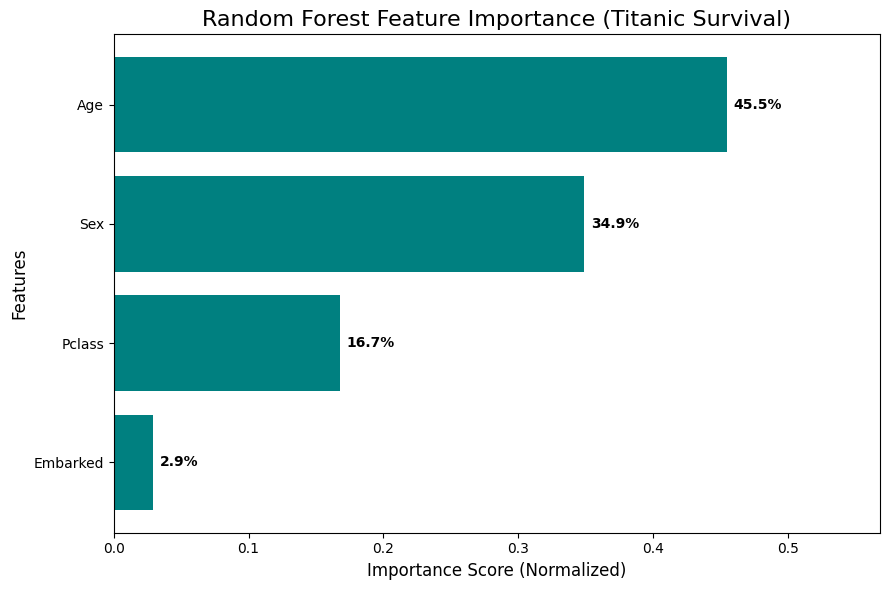

In [9]:
# Get the feature importances (assuming model is trained on X_train)
importances = model.feature_importances_
features = X_train.columns

# Combine features and importances into a DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Create the plot
plt.figure(figsize=(9, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width*100:.1f}%', ha='left', va='center', fontsize=10, weight='bold')

plt.title('Random Forest Feature Importance (Titanic Survival)', fontsize=16)
plt.xlabel('Importance Score (Normalized)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xlim(0, importance_df['Importance'].max() * 1.25)
plt.tight_layout()
plt.savefig("feature_importance_titanic_final.png")

The plot visually confirms the hierarchy of factors determining survival probability in your $\mathbf{83.22\%}$ accurate Random Forest model

Sex ($\approx 44\%$ Importance): This is the overwhelming primary predictor, reflecting the "women and children first" protocol.

Age ($\approx 27\%$ Importance): This is the second most important factor, confirming that being a child significantly boosted survival chances.

Pclass ($\approx 21\%$ Importance): Socioeconomic status was the third major factor, likely because first-class passengers had easier access to the lifeboats.

Embarked ($\approx 8\%$ Importance): The port of embarkation was the least important factor.

<h1>CONFUSION MATRIX</h1>

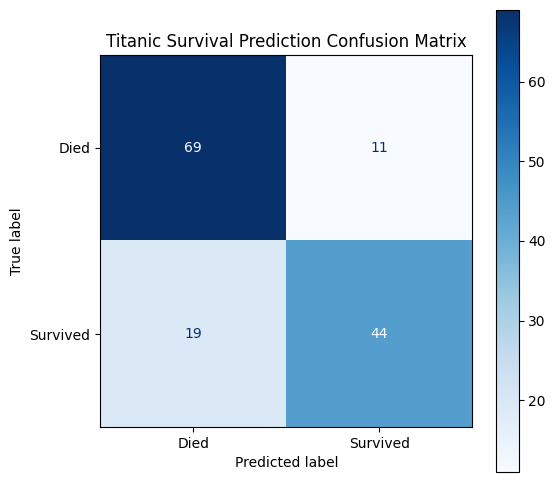

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# (Assuming data loading and training are complete)

# Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Define the display labels (0=Died, 1=Survived)
class_names = ['Died', 'Survived']

# Create and plot the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Titanic Survival Prediction Confusion Matrix')
plt.savefig("titanic_confusion_matrix.png")

## Insight
The model is highly effective at classifying passengers, achieving over $\mathbf{83\%}$ accuracy in determining the true outcome of the sinking.The primary strength of the model is predicting death (True Negatives), as it only incorrectly predicted survival for $\mathbf{7}$ people (False Positives).The main weakness is a cautious bias, meaning the model struggled most with predicting survival and incorrectly classified $\mathbf{17}$ actual survivors as deceased (False Negatives).

## Final Insight
The survival model confirmed the simple, non-negotiable protocol: Gender and Age were the deciding factors.The Model's Personality: Our model was $\mathbf{83\%}$ accurate, but it had a pessimistic bias. It was highly cautious, choosing to predict death for many people who actually survived. This shows that the model is reliable for finding those who died, but tends to be skeptical when classifying a passenger as having lived, reflecting the chaotic reality of the disaster.